In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np
import pandas as pd
import h5py

In [3]:
def inspect_hdf5(path_h5:str):
    """Recursively print all fields in the hdf5 with their shape and dtype"""
    print(f"Inspecting file {path_h5}")
    def inspect_hdf5_rec(item):
        if isinstance(item, h5py.Dataset):
            print(item.name, item.shape, item.dtype, item.chunks)
        else:
            for child in item.values():
                inspect_hdf5_rec(child)
    with h5py.File(path_h5, "r") as file_h5:
        inspect_hdf5_rec(file_h5)
    print()

# Bam to hdf5

In [4]:
from hapROH.utils.bam2hdf5 import bam2hdf5s

In [5]:
prefix_ref_HDF5 = "../Data/reference/1000g_maf5_hdf5/maf5_chr"
path_meta_ref = "../Data/reference/meta_1000g.csv"

In [6]:
sample_name = "SB606"
path_sample_bam = f"../Data/ExampleData/med_jews/bam/{sample_name}.merged.rg.markdup.indrealn_recalibrated.bam"
dir_sample_HDF5 = f"../Data/ExampleData/med_jews/HDF5"
prefix_sample_HDF5 = dir_sample_HDF5 + f"/{sample_name}.chr"

In [7]:
bam2hdf5s(path_sample_bam, prefix_ref_HDF5, dir_sample_HDF5, sample_name, overwrite=False)

File ../Data/ExampleData/med_jews/HDF5/SB606.chr1.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr2.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr3.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr4.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr5.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr6.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr7.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr8.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med_jews/HDF5/SB606.chr9.hdf5 exists already and overwrite=False. Nothing happend.
File ../Data/ExampleData/med

## Inspect hdf5

In [8]:
chrom = 1
path_sample = prefix_sample_HDF5 + f"{chrom}.hdf5"
path_ref = prefix_ref_HDF5 + f"{chrom}.hdf5"

In [9]:
inspect_hdf5(path_sample)
inspect_hdf5(path_ref)

Inspecting file ../Data/ExampleData/med_jews/HDF5/SB606.chr1.hdf5
/calldata/AD (63250, 1, 2) int64 None
/samples (1,) |S50 None
/variants/ALT (63250,) |S1 None
/variants/CHROM (63250,) int64 None
/variants/MAP (63250,) float64 None
/variants/POS (63250,) int64 None
/variants/REF (63250,) |S1 None

Inspecting file ../Data/reference/1000g_maf5_hdf5/maf5_chr1.hdf5
/calldata/GT (530434, 2504, 2) int8 (4145, 40, 1)
/samples (2504,) object None
/variants/ALT (530434,) object None
/variants/MAP (530434,) float32 None
/variants/POS (530434,) int32 None
/variants/REF (530434,) object None



## Time needed to load data from hdf5

In [10]:
file_ref = h5py.File(path_ref)
file_ref["calldata/GT"].shape

(530434, 2504, 2)

In [11]:
nb_subset = 15580
nb_total = file_ref["calldata/GT"].shape[0]
idx_samples = np.random.choice(nb_total, nb_subset,replace=False)
idx_samples.sort()
idx_samples

array([    37,     55,     84, ..., 530326, 530399, 530409],
      shape=(15580,))

In [12]:
# %%time
# # load first all samples, then subset
# data = file_ref["calldata/GT"][:]
# datat = data[idx_samples]

In [13]:
# %%time
# # load only subset: slightly slower on cluster, slightly faster on Florence's laptop because more limited RAM ?)
# data = file_ref["calldata/GT"][idx_samples,:,:]

In [14]:
file_ref.close()

Note about data loading:
- for chrom 1: shape (530434, 2504, 2); dtype int8; chunks (4145, 40, 1)
    - on eva cluster: faster to load eveything in memory then subset
    - on my laptop: slightly faster to load only the subset
- for chrom 19: shape (163160, 2504, 2); dtype int8; chunks (2550, 40, 1)
    - on eva cluster:  ???
    - on my laptop: way faster to load everything in memory then subset over individuals (8s against 18s)


# Call ROH
Note about the performance of both methods:
- in both cases, main time is spent loading the reference panel
    - -> expected gain from storing and using ref_panel as packed bit array
- for smaller SNP sets (chrom 20 from Levant, nb_snp=23 891):
    - new method is faster (~13s vs ~16s on Florence's laptop)
    - possible reason: more efficient computation of emission and transmission matrices ?
- for larger SNP sets (chrom 1 from Levant, nb_snp=72 967):
    - trend inverses: older version becomes faster (40s vs 42s on Florence's laptop)
    - possible reason: time for fwd+bwd pass (pure python loop+numpy) becomes non-negligible
        - -> expected gain from cython implementation

In [15]:
# medieval jews
chrom = 3
sample_name = "SB606"
path_sample = f"../Data/ExampleData/med_jews/HDF5/{sample_name}.chr{chrom}.hdf5"

folder_out_base = "../Data/Output/med_jews"  # Folder where you want to save the results to 

In [24]:
# Levant dataset
chrom = 20
sample_name = "I1178"
path_sample = "../Data/ExampleData/Levant_ChL/Levant_ChL"   # The path before the .ind, .snp, .geno

folder_out_base = "../Data/Output/Levant"  # Folder where you want to save the results to 

## New method

In [17]:
from hapROH.run_new import callROH_chr

In [25]:
%%time
folder_out_roh = folder_out_base + "_new_version"
# iids = None      # all individuals in input file will be processed simoultaneously
iids = sample_name
post_pb = callROH_chr(path_sample, prefix_ref_HDF5+f"{chrom}.hdf5", chrom, iids=iids,
            folder_out=folder_out_roh, logfile=None, loglevel=2)

17:04:01.695 [INFO] hapROH.run_new: Starting callROH_chr on chromosome 20 and iids I1178
17:04:01.696 [INFO] hapROH.run_new: Sample file: ../Data/ExampleData/Levant_ChL/Levant_ChL
17:04:01.697 [INFO] hapROH.run_new: Reference file: ../Data/reference/1000g_maf5_hdf5/maf5_chr20.hdf5


17:04:01.698 [INFO] hapROH.run_new: Loading SNP and computing intersection
17:04:02.970 [DEBUG] hapROH.classes.genomicData: Kept 150277/150277 biallelic SNP sites
17:04:03.027 [DEBUG] hapROH.classes.genomicData: Field `chrom` not found in `snp_ref`
17:04:03.049 [DEBUG] hapROH.classes.genomicData: 23891/150277 SNP found in intersection, of which 0 flipped REF/ALT and 0 mismatching REF/ALT
17:04:03.131 [INFO] hapROH.run_new: Found 23891 intersecting SNP, of which 0 flipped REF/ALT
17:04:03.133 [INFO] hapROH.classes.genomicData: Minimum Genetic Map: 1.1000000085914508e-05 Morgan
17:04:03.134 [INFO] hapROH.classes.genomicData: Maximum Genetic Map: 1.0821340084075928 Morgan
17:04:03.135 [INFO] hapROH.classes.genomicData: Gaps bigger than 0.1 cM: 146
17:04:03.135 [INFO] hapROH.classes.genomicData: Maximum Gap: 0.4744 cM
17:04:03.136 [INFO] hapROH.classes.genomicData: Clipping gaps to range: 0.000 - inf cM
17:04:03.137 [INFO] hapROH.run_new: Loading genotype data
17:04:03.137 [INFO] hapROH.cl

## Old method

In [19]:
from hapsburg.PackagesSupport.hapsburg_run import hapsb_ind

In [26]:
%%time
# not working if hdf5 contains only field AD but not GT, altough GT is only used for display
folder_out_roh = folder_out_base + "_old_version"
df_roh = hapsb_ind(iid=sample_name, chs=[chrom], 
           path_targets=path_sample,
           h5_path1000g=prefix_ref_HDF5,
           meta_path_ref=path_meta_ref,
           p_model="HDF5" if path_sample.endswith(".hdf5") else "Eigenstrat",
           folder_out=folder_out_roh,
           processes=1, output=True,
           readcounts=False, logfile=True, combine=True)

## Plot results

### New plotter

In [21]:
from hapROH.figures.plot_posterior import plot_posterior_cm

16:58:51.626 [DEBUG] hapROH.figures.plot_posterior: Loaded following data: dict_keys(['hap', 'pos', 'map', 'posterior0', 'roh'])


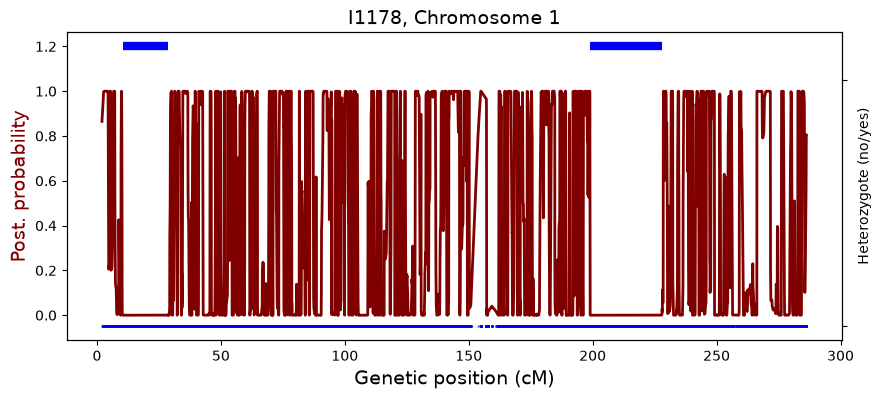

In [22]:
folder_results = os.path.join(folder_out_base + "_old_version", sample_name, "chr" + str(chrom), "")
fig = plot_posterior_cm(folder=folder_results, savepath=None, 
                  min_reads=1, min_cm=1,
                  figsize=(10,4), title=f"{sample_name}, Chromosome {chrom}")

16:58:52.219 [DEBUG] hapROH.figures.plot_posterior: Loaded following data: dict_keys(['gt_count', 'pos', 'map', 'posterior0', 'roh'])


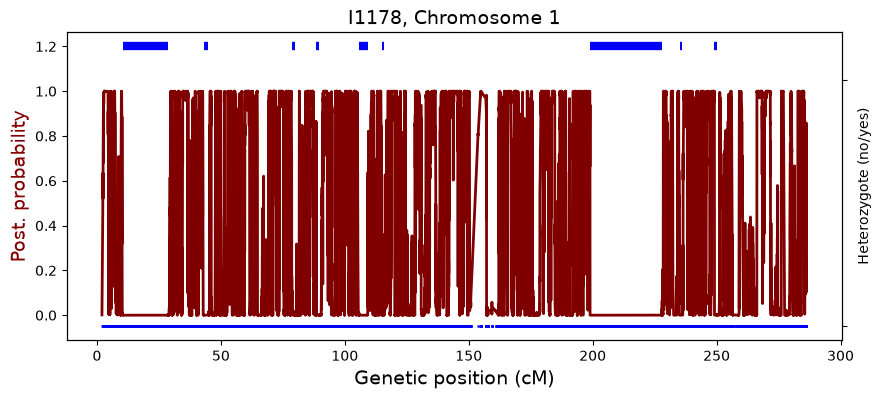

In [23]:
folder_results = os.path.join(folder_out_base + "_new_version", sample_name, "chr" + str(chrom), "")
fig = plot_posterior_cm(folder=folder_results, savepath=None, 
                  min_reads=1, min_cm=1,
                  figsize=(10,4), title=f"{sample_name}, Chromosome {chrom}")